# Extracted Features NaN Analysis

This notebook scans all CSV files in `../extracted_features/` and reports:
- How many NaN values appear in each file
- Which columns are most susceptible to NaNs
- Visual comparisons across files and columns

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)

In [3]:
base_dir = Path("../extracted_features")
csv_paths = sorted(base_dir.rglob("*.csv"))

if not csv_paths:
    raise FileNotFoundError(f"No CSV files found under {base_dir.resolve()}")

print(f"Found {len(csv_paths)} CSV files:")
for p in csv_paths:
    print(" -", p.relative_to(base_dir))

Found 15 CSV files:
 - mfcc/mfcc_features.csv
 - mfcc/mfcc_features_normalized.csv
 - prosody_energy/prosody_energy_features.csv
 - prosody_pitch/prosody_pitch_features.csv
 - representations/representations_features.csv
 - rhythm_pauses/rhythm_pauses_features.csv
 - smilesets/smilesets_features.csv
 - spectral_shape/spectral_shape_features.csv
 - ssl_embeddings/ssl_embeddings_hubert_features.csv
 - ssl_embeddings/ssl_embeddings_wav2vec_features.csv
 - text/bert_embeddings.csv
 - text/tfidf_features.csv
 - text/tfidf_vocabulary.csv
 - tonality/tonality_features.csv
 - voice_quality/voice_quality_features.csv


In [4]:
file_summaries = []
column_summaries = []
dataframes = {}

for path in csv_paths:
    rel = str(path.relative_to(base_dir))
    df = pd.read_csv(path)
    dataframes[rel] = df

    nan_counts = df.isna().sum()
    total_nans = int(nan_counts.sum())
    rows, cols = df.shape

    file_summaries.append({
        "file": rel,
        "rows": rows,
        "columns": cols,
        "total_cells": int(rows * cols),
        "total_nans": total_nans,
        "nan_pct_of_cells": (total_nans / (rows * cols) * 100) if rows * cols else 0.0,
        "columns_with_nan": int((nan_counts > 0).sum()),
        "rows_with_nan": int(df.isna().any(axis=1).sum())
    })

    col_df = pd.DataFrame({
        "file": rel,
        "column": nan_counts.index,
        "nan_count": nan_counts.values
    })
    col_df["rows"] = rows
    col_df["nan_pct"] = np.where(rows > 0, col_df["nan_count"] / rows * 100, 0.0)
    column_summaries.append(col_df)

file_summary_df = pd.DataFrame(file_summaries).sort_values("total_nans", ascending=False).reset_index(drop=True)
column_summary_df = pd.concat(column_summaries, ignore_index=True).sort_values(["nan_count", "nan_pct"], ascending=False)

print("Built summary tables:")
print(" - file_summary_df", file_summary_df.shape)
print(" - column_summary_df", column_summary_df.shape)

Built summary tables:
 - file_summary_df (15, 8)
 - column_summary_df (17149, 5)


In [5]:
# File-level NaN overview
file_summary_df

,file,rows,columns,total_cells,total_nans,nan_pct_of_cells,columns_with_nan,rows_with_nan
0,rhythm_pauses/rhythm_pauses_features.csv,9887,17,168079,37192,22.127690,4,9298
1,prosody_pitch/prosody_pitch_features.csv,9887,21,207627,24456,11.778815,3,8152
2,mfcc/mfcc_features.csv,9887,1157,11439259,0,0.000000,0,0
3,prosody_energy/prosody_energy_features.csv,9887,15,148305,0,0.000000,0,0
4,mfcc/mfcc_features_normalized.csv,9887,1157,11439259,0,0.000000,0,0
5,representations/representations_features.csv,9887,143,1413841,0,0.000000,0,0
6,smilesets/smilesets_features.csv,9887,96,949152,0,0.000000,0,0
7,spectral_shape/spectral_shape_features.csv,9887,73,721751,0,0.000000,0,0
8,ssl_embeddings/ssl_embeddings_hubert_features.csv,9887,1546,15285302,0,0.000000,0,0
9,ssl_embeddings/ssl_embeddings_wav2vec_features...,9887,1546,15285302,0,0.000000,0,0


In [6]:
# Columns most susceptible to NaNs across all extracted-feature CSVs
top_n = 40
top_columns = column_summary_df[column_summary_df["nan_count"] > 0].copy()
top_columns["file_column"] = top_columns["file"] + " :: " + top_columns["column"].astype(str)
top_columns.head(top_n)

,file,column,nan_count,rows,nan_pct,file_column
2506,rhythm_pauses/rhythm_pauses_features.csv,rhythm_pause_mean_s,9298,9887,94.042682,rhythm_pauses/rhythm_pauses_features.csv :: rh...
2507,rhythm_pauses/rhythm_pauses_features.csv,rhythm_pause_std_s,9298,9887,94.042682,rhythm_pauses/rhythm_pauses_features.csv :: rh...
2508,rhythm_pauses/rhythm_pauses_features.csv,rhythm_pause_median_s,9298,9887,94.042682,rhythm_pauses/rhythm_pauses_features.csv :: rh...
2509,rhythm_pauses/rhythm_pauses_features.csv,rhythm_pause_max_s,9298,9887,94.042682,rhythm_pauses/rhythm_pauses_features.csv :: rh...
2347,prosody_pitch/prosody_pitch_features.csv,pitch_voicing_prob_mean,8152,9887,82.451704,prosody_pitch/prosody_pitch_features.csv :: pi...
2348,prosody_pitch/prosody_pitch_features.csv,pitch_voicing_prob_min,8152,9887,82.451704,prosody_pitch/prosody_pitch_features.csv :: pi...
2349,prosody_pitch/prosody_pitch_features.csv,pitch_voicing_prob_max,8152,9887,82.451704,prosody_pitch/prosody_pitch_features.csv :: pi...


/tmp/ipykernel_2358612/3098371431.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="total_nans", y="file", palette="viridis")


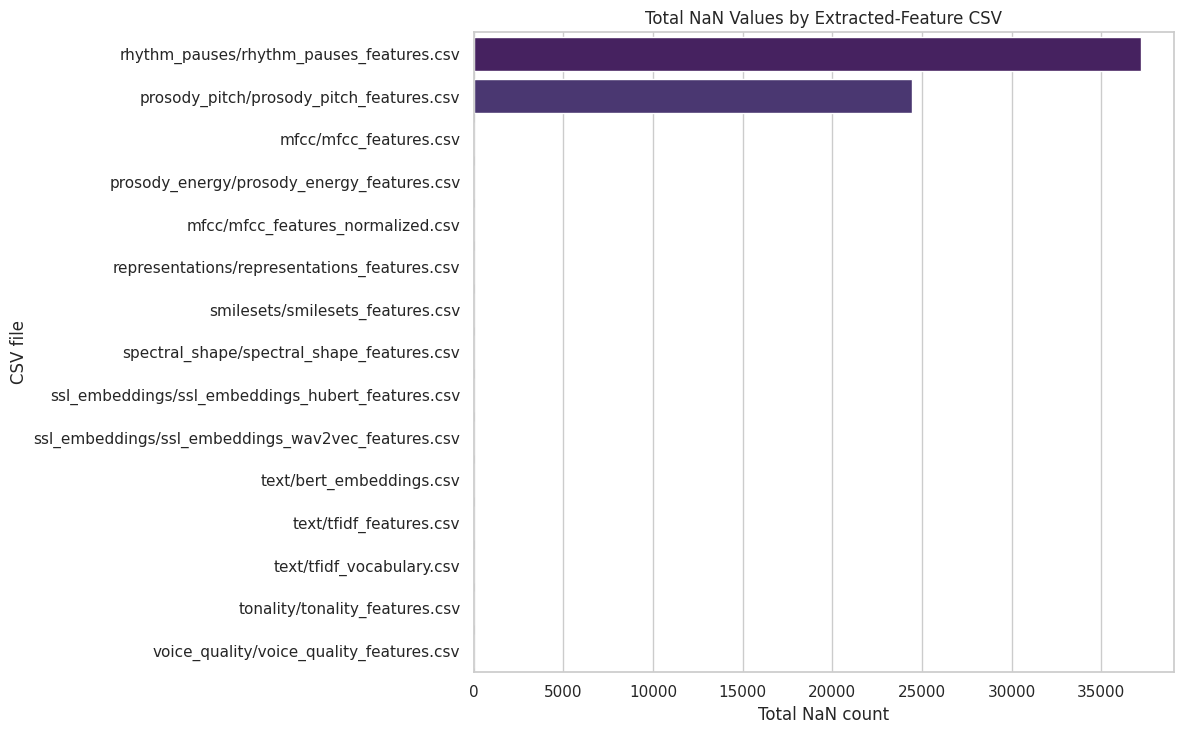

In [7]:
# Visualization 1: total NaNs per file
plot_df = file_summary_df.sort_values("total_nans", ascending=False)

plt.figure(figsize=(12, max(4, 0.5 * len(plot_df))))
sns.barplot(data=plot_df, x="total_nans", y="file", palette="viridis")
plt.title("Total NaN Values by Extracted-Feature CSV")
plt.xlabel("Total NaN count")
plt.ylabel("CSV file")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2358612/3872439240.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_cols, x="nan_pct", y="file_column", palette="magma")


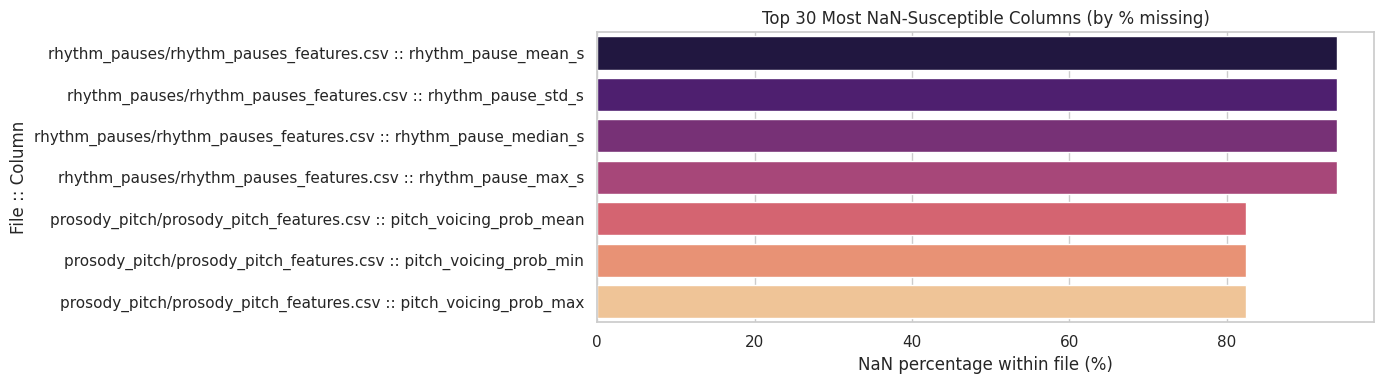

In [8]:
# Visualization 2: top columns by NaN percentage
top_n = 30
plot_cols = top_columns.sort_values(["nan_pct", "nan_count"], ascending=False).head(top_n).copy()

plt.figure(figsize=(14, max(4, 0.4 * len(plot_cols))))
sns.barplot(data=plot_cols, x="nan_pct", y="file_column", palette="magma")
plt.title(f"Top {top_n} Most NaN-Susceptible Columns (by % missing)")
plt.xlabel("NaN percentage within file (%)")
plt.ylabel("File :: Column")
plt.tight_layout()
plt.show()

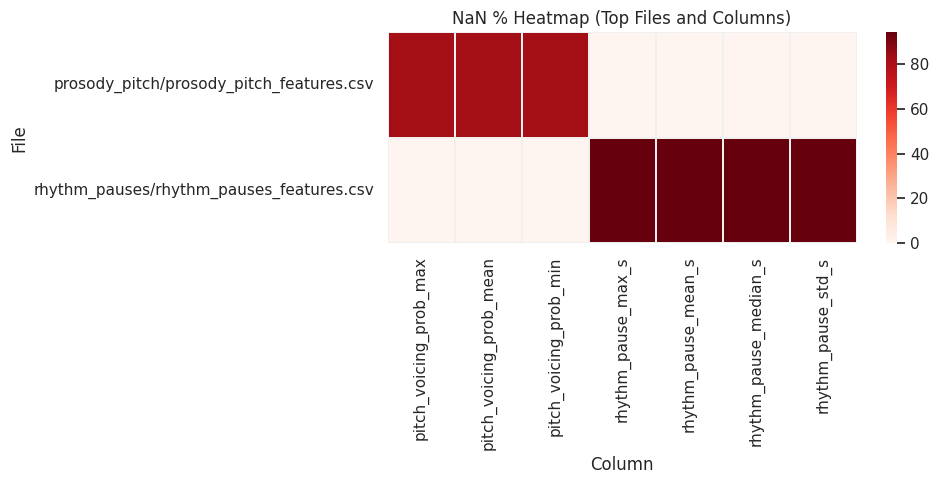

In [9]:
# Visualization 3: heatmap of NaN % for the top files/columns
top_files = file_summary_df.head(10)["file"].tolist()
top_columns_only = (
    column_summary_df[column_summary_df["nan_count"] > 0]
    .groupby("column", as_index=False)["nan_count"].sum()
    .sort_values("nan_count", ascending=False)
    .head(20)["column"]
    .tolist()
)

hm = column_summary_df[
    column_summary_df["file"].isin(top_files) & column_summary_df["column"].isin(top_columns_only)
]
pivot = hm.pivot_table(index="file", columns="column", values="nan_pct", fill_value=0.0)

if not pivot.empty:
    plt.figure(figsize=(max(10, 0.6 * pivot.shape[1]), max(5, 0.5 * pivot.shape[0])))
    sns.heatmap(pivot, cmap="Reds", linewidths=0.3, linecolor="#f0f0f0")
    plt.title("NaN % Heatmap (Top Files and Columns)")
    plt.xlabel("Column")
    plt.ylabel("File")
    plt.tight_layout()
    plt.show()
else:
    print("No NaN values found for heatmap selection.")

In [10]:
# Optional: quickly inspect one file's NaN profile in detail
example_file = file_summary_df.iloc[0]["file"]
detail = column_summary_df[(column_summary_df["file"] == example_file) & (column_summary_df["nan_count"] > 0)]
print(f"Detailed NaN columns for: {example_file}")
detail.sort_values(["nan_count", "nan_pct"], ascending=False).head(100)

Detailed NaN columns for: rhythm_pauses/rhythm_pauses_features.csv


,file,column,nan_count,rows,nan_pct
2506,rhythm_pauses/rhythm_pauses_features.csv,rhythm_pause_mean_s,9298,9887,94.042682
2507,rhythm_pauses/rhythm_pauses_features.csv,rhythm_pause_std_s,9298,9887,94.042682
2508,rhythm_pauses/rhythm_pauses_features.csv,rhythm_pause_median_s,9298,9887,94.042682
2509,rhythm_pauses/rhythm_pauses_features.csv,rhythm_pause_max_s,9298,9887,94.042682
